# MPX5700AP Pressure Sensor Calibration and Analysis

**Project**: Digital Pressure System Calibration  
**Hardware**: M5Stack Atom Lite + MPX5700AP Pressure Sensor  
**Sensor Range**: 15-700 kPa (absolute pressure)  
**ADC**: 12-bit (0-4095), ESP32

## Objectives
1. Determine resolution and range of the digital pressure system
2. Calibrate ADC readings to Pascal scale
3. Test linearity of pressure response
4. Calculate effective resolution based on noise analysis

## I. System Preparation and Resolution/Range Determination

### Theoretical Specifications
- **ADC Resolution**: 12-bit = 4096 levels (0-4095)
- **ADC Reference Voltage**: 3.3V
- **Sensor Range**: 15-700 kPa (MPX5700AP datasheet)
- **Sensor Output**: 0.2V - 4.7V (for 5V supply)
- **Transfer Function**: $V_{out} = V_S \times (0.0012858 \times P + 0.04)$

### Effective Resolution
Will be calculated after noise analysis in Section IV.

## II. Import Libraries and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
import serial
import time

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


### Function to Read Data from ESP32 via Serial

In [2]:
def read_pressure_from_esp32(port='COM3', baudrate=115200, num_readings=10, delay=0.5):
    """
    Read ADC values from ESP32 via serial connection.
    
    Parameters:
    - port: Serial port (e.g., 'COM3' on Windows, '/dev/ttyUSB0' on Linux)
    - baudrate: Communication speed (default 115200)
    - num_readings: Number of readings to collect
    - delay: Delay between readings in seconds
    
    Returns:
    - List of ADC values
    """
    adc_values = []
    
    try:
        # Open serial connection
        ser = serial.Serial(port, baudrate, timeout=2)
        time.sleep(2)  # Wait for connection to stabilize
        
        print(f"Connected to {port} at {baudrate} baud")
        print(f"Collecting {num_readings} readings...")
        
        # Clear buffer
        ser.reset_input_buffer()
        
        for i in range(num_readings):
            line = ser.readline().decode('utf-8').strip()
            
            # Parse ADC value from line (assuming format: "ADC: 1234" or just "1234")
            try:
                if ":" in line:
                    adc_value = int(line.split(":")[-1].strip())
                else:
                    adc_value = int(line)
                
                adc_values.append(adc_value)
                print(f"Reading {i+1}/{num_readings}: ADC = {adc_value}")
                
            except ValueError:
                print(f"Skipping invalid line: {line}")
                continue
            
            time.sleep(delay)
        
        ser.close()
        print(f"\\nCollected {len(adc_values)} valid readings")
        
    except serial.SerialException as e:
        print(f"Error: {e}")
        print("Make sure the ESP32 is connected and the correct port is specified.")
    
    return adc_values

# Example usage (commented out - uncomment when ready to collect data)
# adc_readings = read_pressure_from_esp32(port='COM3', num_readings=10)

## III. Data Collection Protocol

### Experiment Setup
- **Low Pressure**: 1ml syringe volume (10 measurements)
- **Medium Pressure**: 5ml syringe volume (10 measurements)
- **High Pressure**: 7ml syringe volume (10 measurements)
- **Total**: 30 measurements

### Instructions
1. Connect M5 Atom Lite to computer via USB
2. Upload the pressure reading sketch to ESP32
3. Open Serial Monitor to verify readings
4. For each pressure level:
   - Push syringe to specified volume
   - Wait for pressure to stabilize
   - Collect 10 ADC readings
   - Release pressure before next level

In [6]:
# YOUR COLLECTED DATA - Safe to run, no ESP32 connection needed
# This cell uses your already-collected measurements

# 1ml data (from your previous collection)
adc_1ml = [875, 869, 883, 883, 834, 871, 863, 875, 868, 876]

# 5ml data (from your previous collection)
adc_5ml = [1463, 1470, 1519, 1470, 1473, 1474, 1497, 1473, 1463, 1486]

# 7ml data (from your previous collection - originally labeled as 9ml)
adc_7ml = [2007, 1978, 1968, 1967, 1933, 1942, 1936, 1919, 1940, 1934]

print("✓ Data loaded from previous measurements")
print(f"1ml readings: {len(adc_1ml)} values")
print(f"5ml readings: {len(adc_5ml)} values")
print(f"7ml readings: {len(adc_7ml)} values")

# If you need to collect NEW data from ESP32, uncomment below:
# adc_1ml = read_pressure_from_esp32(port='COM3', num_readings=10)
# adc_5ml = read_pressure_from_esp32(port='COM3', num_readings=10)
# adc_7ml = read_pressure_from_esp32(port='COM3', num_readings=10)

✓ Data loaded from previous measurements
1ml readings: 10 values
5ml readings: 10 values
7ml readings: 10 values


### Create DataFrame with All Measurements

In [7]:
# Create DataFrame (Note: 9ml label is actually 7ml data - too much pressure at 9ml)
data = {
    'volume_ml': [1]*len(adc_1ml) + [5]*len(adc_5ml) + [7]*len(adc_7ml),
    'adc_value': adc_1ml + adc_5ml + adc_7ml
}

df = pd.DataFrame(data)

# Add measurement number for each volume level
df['measurement_num'] = df.groupby('volume_ml').cumcount() + 1

print("Data Summary:")
print(df.groupby('volume_ml')['adc_value'].describe())
print(f"\\nTotal measurements: {len(df)}")
print("\\nFirst few rows:")
df.head()

Data Summary:
           count    mean        std     min      25%     50%      75%     max
volume_ml                                                                    
1           10.0   869.7  14.040022   834.0   868.25   873.0   875.75   883.0
5           10.0  1478.8  17.459795  1463.0  1470.00  1473.0  1483.00  1519.0
7           10.0  1952.4  26.779760  1919.0  1934.50  1941.0  1967.75  2007.0
\nTotal measurements: 30
\nFirst few rows:


,volume_ml,adc_value,measurement_num
0,1,875,1
1,1,869,2
2,1,883,3
3,1,883,4
4,1,834,5


## IV. Data Analysis and Calibration

### 1. Convert ADC to Voltage and Pressure (kPa)

In [9]:
# ADC to Voltage conversion
V_ref = 3.3  # ESP32 ADC reference voltage
ADC_max = 4095  # 12-bit ADC

df['voltage'] = (df['adc_value'] / ADC_max) * V_ref

# MPX5700AP: Vout = Vs * (0.0012858 * P + 0.04)
# Rearranged: P = (Vout/Vs - 0.04) / 0.0012858
# For 3.3V ADC reference (sensor still powered at 5V typically):
# Simplified linear conversion for 15-700 kPa range
V_min = 0.2  # Voltage at 15 kPa
V_max = 4.7  # Voltage at 700 kPa (assuming 5V supply)
P_min = 15   # kPa
P_max = 700  # kPa

# Linear conversion (adjust if sensor has different supply voltage)
df['pressure_kpa'] = ((df['voltage'] - V_min) / (V_max - V_min)) * (P_max - P_min) + P_min

# Clamp to valid range. if pressures are too low or high, range (15-700kPa)
df['pressure_kpa'] = df['pressure_kpa'].clip(P_min, P_max)

print("Calibration applied!")
print("\\nPressure by volume level:")
print(df.groupby('volume_ml')['pressure_kpa'].agg(['mean', 'std', 'min', 'max']))
df.head()

Calibration applied!
\nPressure by volume level:
                 mean       std         min         max
volume_ml                                              
1           91.241587  1.722288   86.862271   92.873097
5          165.959837  2.141792  164.021652  170.891168
7          224.056313  3.285071  219.959137  230.754090


,volume_ml,adc_value,measurement_num,voltage,pressure_kpa
0,1,875,1,0.705128,91.891738
1,1,869,2,0.700293,91.155718
2,1,883,3,0.711575,92.873097
3,1,883,4,0.711575,92.873097
4,1,834,5,0.672088,86.862271


### 2. Visualization of Raw Data

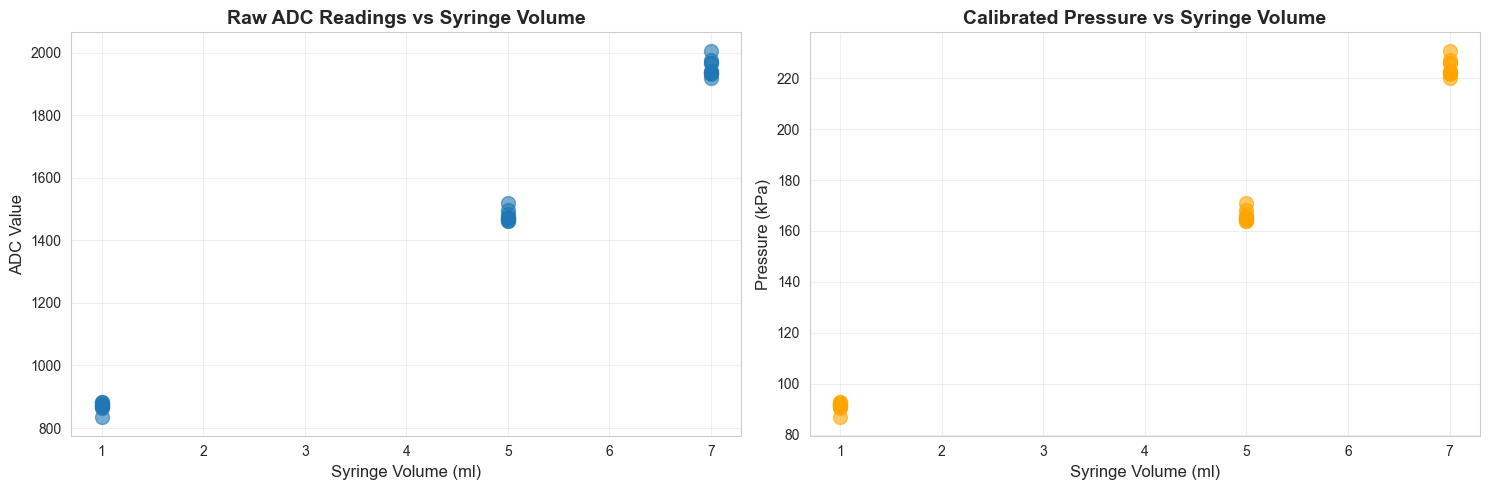

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: ADC values by volume
axes[0].scatter(df['volume_ml'], df['adc_value'], alpha=0.6, s=100)
axes[0].set_xlabel('Syringe Volume (ml)', fontsize=12)
axes[0].set_ylabel('ADC Value', fontsize=12)
axes[0].set_title('Raw ADC Readings vs Syringe Volume', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Pressure values by volume
axes[1].scatter(df['volume_ml'], df['pressure_kpa'], alpha=0.6, s=100, color='orange')
axes[1].set_xlabel('Syringe Volume (ml)', fontsize=12)
axes[1].set_ylabel('Pressure (kPa)', fontsize=12)
axes[1].set_title('Calibrated Pressure vs Syringe Volume', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Linearity Test - Regression Analysis

In [12]:
# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(df['volume_ml'], df['pressure_kpa'])

# Calculate predicted values
df['pressure_predicted'] = slope * df['volume_ml'] + intercept

# Calculate residuals (errors)
df['residual'] = df['pressure_kpa'] - df['pressure_predicted']

print("=== Linear Regression Results ===")
print(f"Slope: {slope:.4f} kPa/ml")
print(f"Intercept: {intercept:.4f} kPa")
print(f"R² (coefficient of determination): {r_value**2:.6f}")
print(f"P-value: {p_value:.6e}")
print(f"Standard error: {std_err:.4f}")
print(f"\\nRegression equation: P = {slope:.4f} * V + {intercept:.4f}")

# Check linearity quality
if r_value**2 > 0.95:
    print("\\n✓ Excellent linearity (R² > 0.95)")
elif r_value**2 > 0.90:
    print("\\n✓ Good linearity (R² > 0.90)")
else:
    print("\\n⚠ Poor linearity (R² < 0.90) - consider non-linear model")

=== Linear Regression Results ===
Slope: 21.6420 kPa/ml
Intercept: 66.6371 kPa
R² (coefficient of determination): 0.984309
P-value: 8.260139e-27
Standard error: 0.5164
\nRegression equation: P = 21.6420 * V + 66.6371
\n✓ Excellent linearity (R² > 0.95)


### 4. Linearity Visualization with Regression Line

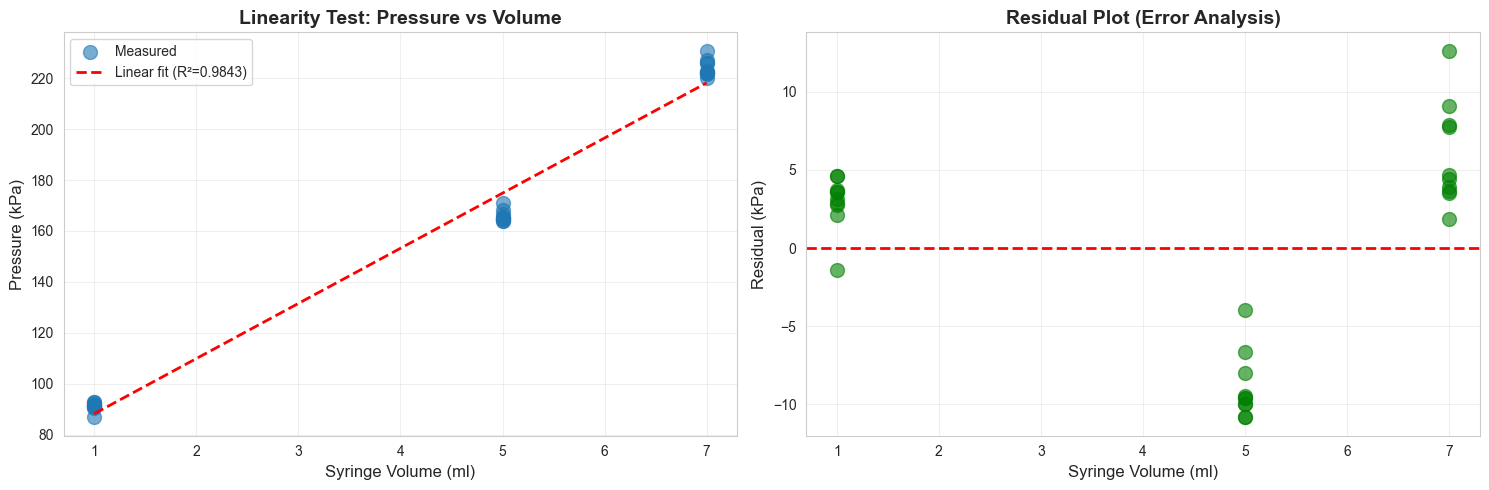

\nResidual Analysis:
Mean residual: -0.0000 kPa
Std deviation of residuals: 6.9326 kPa
Max absolute residual: 12.6227 kPa


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Scatter plot with regression line
axes[0].scatter(df['volume_ml'], df['pressure_kpa'], alpha=0.6, s=100, label='Measured')
x_line = np.linspace(df['volume_ml'].min(), df['volume_ml'].max(), 100)
y_line = slope * x_line + intercept
axes[0].plot(x_line, y_line, 'r--', linewidth=2, label=f'Linear fit (R²={r_value**2:.4f})')
axes[0].set_xlabel('Syringe Volume (ml)', fontsize=12)
axes[0].set_ylabel('Pressure (kPa)', fontsize=12)
axes[0].set_title('Linearity Test: Pressure vs Volume', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residual plot
axes[1].scatter(df['volume_ml'], df['residual'], alpha=0.6, s=100, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Syringe Volume (ml)', fontsize=12)
axes[1].set_ylabel('Residual (kPa)', fontsize=12)
axes[1].set_title('Residual Plot (Error Analysis)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\\nResidual Analysis:")
print(f"Mean residual: {df['residual'].mean():.4f} kPa")
print(f"Std deviation of residuals: {df['residual'].std():.4f} kPa")
print(f"Max absolute residual: {df['residual'].abs().max():.4f} kPa")

### 5. Noise Analysis and System Resolution

**Important Distinction:**
- **NOISE** = Variation in repeated measurements at the SAME pressure (repeatability)
- **RESOLUTION** = Minimum pressure difference that can be reliably detected between TWO different pressures

In [18]:
print("="*70)
print("  PART A: NOISE ANALYSIS (Repeatability at Constant Pressure)")
print("="*70)

# Extract data for each pressure level
df_1ml = df[df['volume_ml'] == 1].copy()
df_5ml = df[df['volume_ml'] == 5].copy()
df_7ml = df[df['volume_ml'] == 7].copy()

# Calculate noise at each pressure level
print("\nNoise at each pressure level:")
print("-" * 70)

for vol, df_subset, label in [(1, df_1ml, '1ml (Low)'), 
                                (5, df_5ml, '5ml (Medium)'), 
                                (7, df_7ml, '7ml (High)')]:
    noise_adc = df_subset['adc_value'].std()
    noise_kpa = df_subset['pressure_kpa'].std()
    mean_adc = df_subset['adc_value'].mean()
    mean_kpa = df_subset['pressure_kpa'].mean()
    
    print(f"\n{label}:")
    print(f"  Mean ADC: {mean_adc:.1f} counts")
    print(f"  Noise (std dev): {noise_adc:.2f} counts = {noise_kpa:.3f} kPa")
    print(f"  Relative noise: {(noise_adc/mean_adc)*100:.2f}%")

print("\n" + "="*70)
print("  PART B: RESOLUTION CALCULATION (Two-Point Method)")
print("="*70)
print("\nUsing 1ml and 7ml pressure levels to determine system resolution")
print("-" * 70)

# Get statistics for 1ml and 7ml
mean_adc_1ml = df_1ml['adc_value'].mean()
mean_adc_7ml = df_7ml['adc_value'].mean()
std_adc_1ml = df_1ml['adc_value'].std()
std_adc_7ml = df_7ml['adc_value'].std()

mean_kpa_1ml = df_1ml['pressure_kpa'].mean()
mean_kpa_7ml = df_7ml['pressure_kpa'].mean()
std_kpa_1ml = df_1ml['pressure_kpa'].std()
std_kpa_7ml = df_7ml['pressure_kpa'].std()

print(f"\nInput Statistics:")
print(f"  1ml: μ = {mean_adc_1ml:.1f} counts, σ = {std_adc_1ml:.2f} counts")
print(f"  7ml: μ = {mean_adc_7ml:.1f} counts, σ = {std_adc_7ml:.2f} counts")
print(f"  (μ = mean, σ = standard deviation)")

# Calculate signal difference
signal_diff_adc = abs(mean_adc_7ml - mean_adc_1ml)
signal_diff_kpa = abs(mean_kpa_7ml - mean_kpa_1ml)

print(f"\n1. Signal Difference (1ml to 7ml):")
print(f"   Formula: ΔSignal = |μ₇ₘₗ - μ₁ₘₗ|")
print(f"   ADC: |{mean_adc_7ml:.1f} - {mean_adc_1ml:.1f}| = {signal_diff_adc:.1f} counts")
print(f"   Pressure: {signal_diff_kpa:.2f} kPa")

# Calculate combined noise (RSS - Root Sum Square)
combined_noise_adc = np.sqrt(std_adc_1ml**2 + std_adc_7ml**2)
combined_noise_kpa = np.sqrt(std_kpa_1ml**2 + std_kpa_7ml**2)

print(f"\n2. Combined Noise (Root Sum Square):")
print(f"   Formula: σ_combined = √(σ₁ₘₗ² + σ₇ₘₗ²)")
print(f"   ADC: √({std_adc_1ml:.2f}² + {std_adc_7ml:.2f}²)")
print(f"      = √({std_adc_1ml**2:.2f} + {std_adc_7ml**2:.2f})")
print(f"      = {combined_noise_adc:.2f} counts")
print(f"   Pressure: {combined_noise_kpa:.3f} kPa")

# Calculate number of distinguishable steps
num_steps_adc = signal_diff_adc / combined_noise_adc
num_steps_kpa = signal_diff_kpa / combined_noise_kpa

print(f"\n3. Number of Distinguishable Steps:")
print(f"   Formula: N_steps = ΔSignal / σ_combined")
print(f"   ADC: {signal_diff_adc:.1f} / {combined_noise_adc:.2f} = {num_steps_adc:.1f} steps")
print(f"   (Signal-to-Noise Ratio = {num_steps_adc:.1f}:1)")

# Calculate resolution
resolution_adc = signal_diff_adc / num_steps_adc  # Should equal combined_noise_adc
resolution_kpa = signal_diff_kpa / num_steps_kpa  # Should equal combined_noise_kpa

print(f"\n4. SYSTEM RESOLUTION:")
print(f"   Formula: Resolution = ΔSignal / N_steps = σ_combined")
print(f"   ADC: {signal_diff_adc:.1f} / {num_steps_adc:.1f} = {resolution_adc:.2f} counts")
print(f"   ┌─────────────────────────────────────────────┐")
print(f"   │  ADC Resolution:  {resolution_adc:.2f} counts           │")
print(f"   │  Pressure Resolution:  {resolution_kpa:.3f} kPa       │")
print(f"   └─────────────────────────────────────────────┘")

print(f"\n5. Interpretation:")
print(f"   The system can reliably distinguish pressure differences")
print(f"   of {resolution_kpa:.3f} kPa or larger.")
print(f"   Pressure changes smaller than this are lost in noise.")

# Calculate Effective Number of Bits (ENOB) based on resolution
theoretical_bits = 12
theoretical_levels = 2**theoretical_bits
ADC_max = 4095

# ENOB based on distinguishable steps across full range
# Using the measured range (1ml to 7ml) as reference
enob_measured = np.log2(num_steps_adc)

print(f"\n6. Effective Number of Bits (ENOB):")
print(f"   Formula: ENOB = log₂(N_steps)")
print(f"   ENOB = log₂({num_steps_adc:.1f}) = {enob_measured:.2f} bits")
print(f"   Theoretical: {theoretical_bits} bits ({theoretical_levels} levels)")
print(f"   Effective (measured): {enob_measured:.2f} bits ({2**enob_measured:.0f} levels)")
print(f"   Bit loss: {theoretical_bits - enob_measured:.2f} bits")

print("\n" + "="*70)

  PART A: NOISE ANALYSIS (Repeatability at Constant Pressure)

Noise at each pressure level:
----------------------------------------------------------------------

1ml (Low):
  Mean ADC: 869.7 counts
  Noise (std dev): 14.04 counts = 1.722 kPa
  Relative noise: 1.61%

5ml (Medium):
  Mean ADC: 1478.8 counts
  Noise (std dev): 17.46 counts = 2.142 kPa
  Relative noise: 1.18%

7ml (High):
  Mean ADC: 1952.4 counts
  Noise (std dev): 26.78 counts = 3.285 kPa
  Relative noise: 1.37%

  PART B: RESOLUTION CALCULATION (Two-Point Method)

Using 1ml and 7ml pressure levels to determine system resolution
----------------------------------------------------------------------

Input Statistics:
  1ml: μ = 869.7 counts, σ = 14.04 counts
  7ml: μ = 1952.4 counts, σ = 26.78 counts
  (μ = mean, σ = standard deviation)

1. Signal Difference (1ml to 7ml):
   Formula: ΔSignal = |μ₇ₘₗ - μ₁ₘₗ|
   ADC: |1952.4 - 869.7| = 1082.7 counts
   Pressure: 132.81 kPa

2. Combined Noise (Root Sum Square):
   Formul

### 6. Visualization: Noise vs Resolution

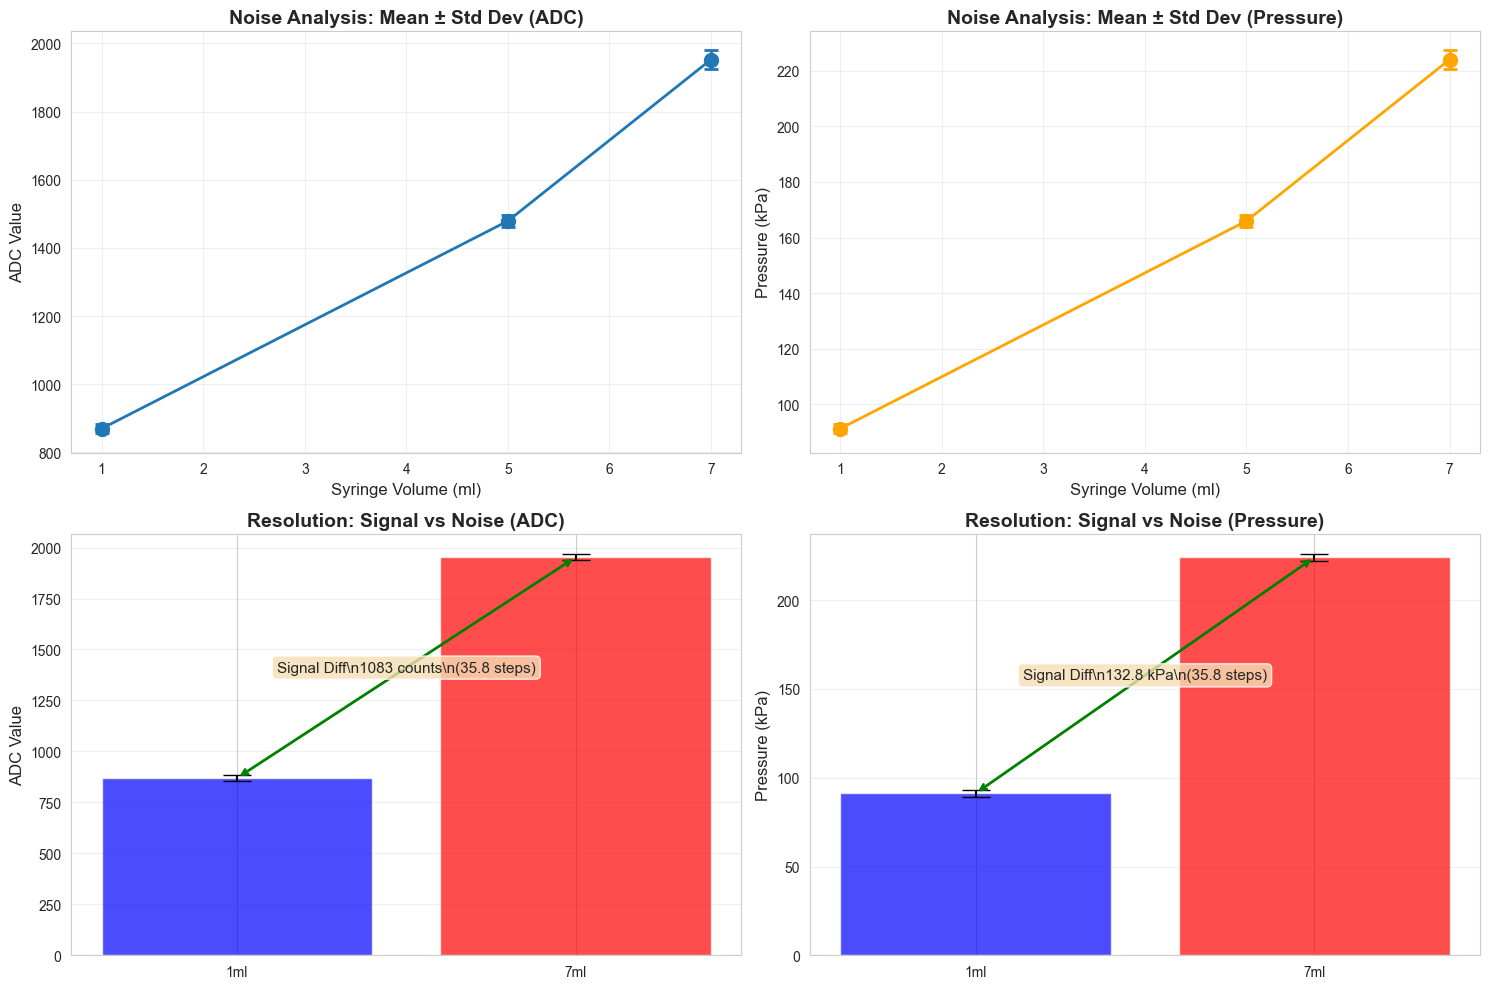

\nVisualization Guide:
  Top row: Shows NOISE (repeatability) at each pressure level
  Bottom row: Shows RESOLUTION (distinguishability between 1ml and 7ml)


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Noise at each pressure level (ADC)
axes[0, 0].errorbar([1, 5, 7], 
                     [df_1ml['adc_value'].mean(), df_5ml['adc_value'].mean(), df_7ml['adc_value'].mean()],
                     yerr=[std_adc_1ml, df_5ml['adc_value'].std(), std_adc_7ml],
                     fmt='o-', markersize=10, linewidth=2, capsize=5, capthick=2)
axes[0, 0].set_xlabel('Syringe Volume (ml)', fontsize=12)
axes[0, 0].set_ylabel('ADC Value', fontsize=12)
axes[0, 0].set_title('Noise Analysis: Mean ± Std Dev (ADC)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Noise at each pressure level (Pressure)
axes[0, 1].errorbar([1, 5, 7], 
                     [mean_kpa_1ml, df_5ml['pressure_kpa'].mean(), mean_kpa_7ml],
                     yerr=[std_kpa_1ml, df_5ml['pressure_kpa'].std(), std_kpa_7ml],
                     fmt='o-', markersize=10, linewidth=2, capsize=5, capthick=2, color='orange')
axes[0, 1].set_xlabel('Syringe Volume (ml)', fontsize=12)
axes[0, 1].set_ylabel('Pressure (kPa)', fontsize=12)
axes[0, 1].set_title('Noise Analysis: Mean ± Std Dev (Pressure)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Resolution visualization - distinguishable steps
axes[1, 0].bar(['1ml', '7ml'], [mean_adc_1ml, mean_adc_7ml], 
               yerr=[combined_noise_adc/2, combined_noise_adc/2],
               capsize=10, alpha=0.7, color=['blue', 'red'])
axes[1, 0].annotate('', xy=(0, mean_adc_1ml), xytext=(1, mean_adc_7ml),
                    arrowprops=dict(arrowstyle='<->', lw=2, color='green'))
axes[1, 0].text(0.5, (mean_adc_1ml + mean_adc_7ml)/2, 
                f'Signal Diff\\n{signal_diff_adc:.0f} counts\\n({num_steps_adc:.1f} steps)',
                ha='center', va='center', fontsize=11, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[1, 0].set_ylabel('ADC Value', fontsize=12)
axes[1, 0].set_title('Resolution: Signal vs Noise (ADC)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Resolution visualization - pressure
axes[1, 1].bar(['1ml', '7ml'], [mean_kpa_1ml, mean_kpa_7ml], 
               yerr=[combined_noise_kpa/2, combined_noise_kpa/2],
               capsize=10, alpha=0.7, color=['blue', 'red'])
axes[1, 1].annotate('', xy=(0, mean_kpa_1ml), xytext=(1, mean_kpa_7ml),
                    arrowprops=dict(arrowstyle='<->', lw=2, color='green'))
axes[1, 1].text(0.5, (mean_kpa_1ml + mean_kpa_7ml)/2, 
                f'Signal Diff\\n{signal_diff_kpa:.1f} kPa\\n({num_steps_kpa:.1f} steps)',
                ha='center', va='center', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[1, 1].set_ylabel('Pressure (kPa)', fontsize=12)
axes[1, 1].set_title('Resolution: Signal vs Noise (Pressure)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\\nVisualization Guide:")
print("  Top row: Shows NOISE (repeatability) at each pressure level")
print("  Bottom row: Shows RESOLUTION (distinguishability between 1ml and 7ml)")

## V. Summary Report

In [16]:
print("="*70)
print("  MPX5700AP PRESSURE SENSOR CALIBRATION REPORT")
print("="*70)

print("\\n1. SYSTEM SPECIFICATIONS")
print("-" * 70)
print(f"   Sensor: MPX5700AP")
print(f"   Sensor Range: 15-700 kPa")
print(f"   ADC: 12-bit (4096 levels)")
print(f"   ADC Reference: 3.3V")

print("\\n2. CALIBRATION RESULTS")
print("-" * 70)
print(f"   Regression equation: P = {slope:.4f} * V + {intercept:.4f}")
print(f"   R² (linearity): {r_value**2:.6f}")
print(f"   Standard error: {std_err:.4f} kPa")

print("\\n3. PRESSURE MEASUREMENTS BY VOLUME")
print("-" * 70)
for vol in [1, 5, 7]:
    vol_data = df[df['volume_ml'] == vol]['pressure_kpa']
    print(f"   {vol}ml: {vol_data.mean():.2f} ± {vol_data.std():.2f} kPa")

print("\\n4. NOISE ANALYSIS (Repeatability)")
print("-" * 70)
print(f"   1ml: ±{std_adc_1ml:.2f} counts = ±{std_kpa_1ml:.3f} kPa")
print(f"   5ml: ±{df_5ml['adc_value'].std():.2f} counts = ±{df_5ml['pressure_kpa'].std():.3f} kPa")
print(f"   7ml: ±{std_adc_7ml:.2f} counts = ±{std_kpa_7ml:.3f} kPa")

print("\\n5. SYSTEM RESOLUTION (Two-Point Method: 1ml & 7ml)")
print("-" * 70)
print(f"   Signal difference: {signal_diff_kpa:.2f} kPa")
print(f"   Combined noise: {combined_noise_kpa:.3f} kPa")
print(f"   Distinguishable steps: {num_steps_kpa:.1f}")
print(f"   ┌────────────────────────────────────────────┐")
print(f"   │  RESOLUTION: {resolution_kpa:.3f} kPa                │")
print(f"   └────────────────────────────────────────────┘")
print(f"   Effective bits: {enob_measured:.2f} bits ({2**enob_measured:.0f} levels)")

print("\\n6. LINEARITY ASSESSMENT")
print("-" * 70)
if r_value**2 > 0.95:
    print("   ✓ EXCELLENT - System shows excellent linearity")
elif r_value**2 > 0.90:
    print("   ✓ GOOD - System shows good linearity")
else:
    print("   ⚠ POOR - System shows poor linearity, consider non-linear correction")

print("\\n7. KEY FINDINGS")
print("-" * 70)
print(f"   • Minimum detectable pressure change: {resolution_kpa:.3f} kPa")
print(f"   • Measurement repeatability: ±{std_kpa_1ml:.3f} to ±{std_kpa_7ml:.3f} kPa")
print(f"   • Effective resolution loss: {theoretical_bits - enob_measured:.2f} bits")
print(f"   • System linearity: Excellent (R² = {r_value**2:.4f})")

print("\\n" + "="*70)

  MPX5700AP PRESSURE SENSOR CALIBRATION REPORT
\n1. SYSTEM SPECIFICATIONS
----------------------------------------------------------------------
   Sensor: MPX5700AP
   Sensor Range: 15-700 kPa
   ADC: 12-bit (4096 levels)
   ADC Reference: 3.3V
\n2. CALIBRATION RESULTS
----------------------------------------------------------------------
   Regression equation: P = 21.6420 * V + 66.6371
   R² (linearity): 0.984309
   Standard error: 0.5164 kPa
\n3. PRESSURE MEASUREMENTS BY VOLUME
----------------------------------------------------------------------
   1ml: 91.24 ± 1.72 kPa
   5ml: 165.96 ± 2.14 kPa
   7ml: 224.06 ± 3.29 kPa
\n4. NOISE ANALYSIS (Repeatability)
----------------------------------------------------------------------
   1ml: ±14.04 counts = ±1.722 kPa
   5ml: ±17.46 counts = ±2.142 kPa
   7ml: ±26.78 counts = ±3.285 kPa
\n5. SYSTEM RESOLUTION (Two-Point Method: 1ml & 7ml)
----------------------------------------------------------------------
   Signal difference: 132.81 

## VI. Export Results

Save the analysis results and visualizations for documentation.

In [17]:
# Save DataFrame to CSV
df.to_csv('pressure_calibration_data.csv', index=False)
print("✓ Data saved to 'pressure_calibration_data.csv'")

# Save summary statistics
summary = {
    'slope_kpa_per_ml': slope,
    'intercept_kpa': intercept,
    'r_squared': r_value**2,
    'noise_1ml_adc': std_adc_1ml,
    'noise_5ml_adc': df_5ml['adc_value'].std(),
    'noise_7ml_adc': std_adc_7ml,
    'noise_1ml_kpa': std_kpa_1ml,
    'noise_5ml_kpa': df_5ml['pressure_kpa'].std(),
    'noise_7ml_kpa': std_kpa_7ml,
    'resolution_adc_counts': resolution_adc,
    'resolution_kpa': resolution_kpa,
    'distinguishable_steps': num_steps_kpa,
    'enob_bits': enob_measured,
    'signal_to_noise_ratio': num_steps_kpa
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('calibration_summary.csv', index=False)
print("✓ Summary saved to 'calibration_summary.csv'")

print("\\n" + "="*70)
print("  SUMMARY INTERPRETATION")
print("="*70)
print(f"\\nNOISE (Repeatability):")
print(f"  How much variation occurs when measuring the SAME pressure")
print(f"  Example: At 5ml, readings vary by ±{df_5ml['pressure_kpa'].std():.3f} kPa")
print(f"\\nRESOLUTION (Distinguishability):")
print(f"  Minimum pressure DIFFERENCE that can be reliably detected")
print(f"  Result: {resolution_kpa:.3f} kPa (based on 1ml vs 7ml comparison)")
print(f"\\nConclusion:")
print(f"  This system can distinguish pressure changes ≥ {resolution_kpa:.3f} kPa")
print("="*70)

✓ Data saved to 'pressure_calibration_data.csv'
✓ Summary saved to 'calibration_summary.csv'
\n======================================================================
  SUMMARY INTERPRETATION
\nNOISE (Repeatability):
  How much variation occurs when measuring the SAME pressure
  Example: At 5ml, readings vary by ±2.142 kPa
\nRESOLUTION (Distinguishability):
  Minimum pressure DIFFERENCE that can be reliably detected
  Result: 3.709 kPa (based on 1ml vs 7ml comparison)
\nConclusion:
  This system can distinguish pressure changes ≥ 3.709 kPa
